In [5]:
import sys
from pathlib import Path

# Assumes notebook is in notebooks/ folder
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.data_loader import get_train_val_test  # change if your function name differs
from src.preprocess import apply_cleaning

X_train, X_val, X_test, y_train, y_val, y_test = get_train_val_test(
    "../data/raw/train.csv",
    "../data/raw/test.csv"
)

X_train_clean = apply_cleaning(X_train)
X_val_clean   = apply_cleaning(X_val)
X_test_clean  = apply_cleaning(X_test)

In [6]:
import os
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, f1_score, classification_report

MODEL_PATH = "../models/best_model.pkl"
os.makedirs("../reports/metrics", exist_ok=True)

model = joblib.load(MODEL_PATH)

y_pred = model.predict(X_test_clean)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

df = pd.DataFrame([{
    "model_path": MODEL_PATH,
    "accuracy": acc,
    "macro_f1": macro_f1
}])

df.to_csv("../reports/metrics/week5_best_model_metrics.csv", index=False)
print(df)
print("\nClassification report:\n", classification_report(y_test, y_pred))


                 model_path  accuracy  macro_f1
0  ../models/best_model.pkl  0.901711  0.901452

Classification report:
               precision    recall  f1-score   support

           1       0.92      0.89      0.91      1900
           2       0.94      0.98      0.96      1900
           3       0.87      0.86      0.87      1900
           4       0.87      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



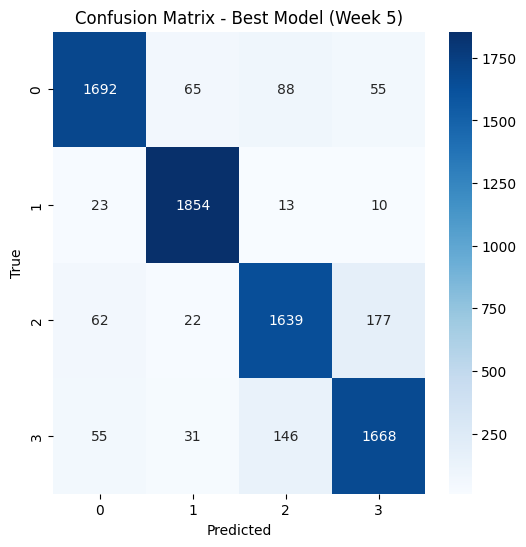

In [7]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Best Model (Week 5)")
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/week5_confusion_matrix_best_model.png", bbox_inches="tight")
plt.show()


In [8]:
import numpy as np
import pandas as pd
import os

os.makedirs("../reports/metrics", exist_ok=True)

mis_idx = np.where(y_test.to_numpy() != y_pred)[0]

rows = []
for i in mis_idx[:50]:
    rows.append({
        "true": int(y_test.iloc[i]),
        "pred": int(y_pred[i]),
        "text_snippet": str(X_test.iloc[i])[:250]
    })

pd.DataFrame(rows).to_csv("../reports/metrics/week5_misclassified_samples.csv", index=False)
print("Saved: ../reports/metrics/week5_misclassified_samples.csv")


Saved: ../reports/metrics/week5_misclassified_samples.csv
